In [1]:
import matplotlib.pyplot as plt  
import numpy as np 
import pandas as pd 
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
X,Y=make_classification(n_samples=300,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    flip_y=0.1,  # 10% noise to make it realistic
    random_state=42)

In [3]:
Y = Y.reshape(-1, 1)  # Reshape for easier calculations

# Split into train/test
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Standardize features (important for gradient descent)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4]:
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")

Training samples: 240
Test samples: 60
Features: 2


C:\Users\Rupak\AppData\Local\Temp\ipykernel_9000\1692997263.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


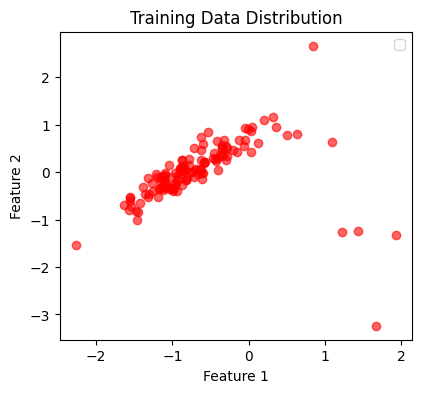

In [5]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(X_train[Y_train.flatten()==0, 0],X_train[Y_train.flatten()==0,1],c='red',alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Training Data Distribution')
plt.legend()

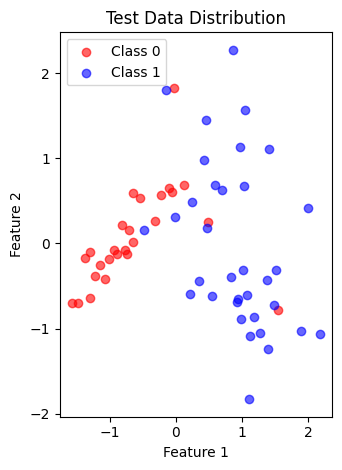

In [6]:
plt.subplot(1, 2, 2)
plt.scatter(X_test[Y_test.flatten()==0, 0], X_test[Y_test.flatten()==0, 1], 
            c='red', label='Class 0', alpha=0.6)
plt.scatter(X_test[Y_test.flatten()==1, 0], X_test[Y_test.flatten()==1, 1], 
            c='blue', label='Class 1', alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Test Data Distribution')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# ============================================
# PART 2: IMPLEMENT STEP FUNCTION PERCEPTRON
# ============================================
class stepPerceptron: 
    def __init__(self,learningRate=0.01,epochs=1000): 
        self.lr = learningRate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.losses = []
        
    def step_function(self, x):
        """Step activation: returns 1 if x>=0 else 0"""
        return np.where(x >= 0, 1, 0)
    
    def forward(self, X):
        """Forward pass"""
        linear_output = np.dot(X, self.weights) + self.bias
        return self.step_function(linear_output)
    
    def compute_loss(self, y_true, y_pred):
        """Simple accuracy-based loss (not differentiable)"""
        return np.mean(y_true != y_pred)

    def train(self,X,Y): 
        samples,features=X.shape

        self.weights=np.random.randn(features,1)*0.01 
        self.bias=0
        self.losses=[] 

        print("Training Perceptron") 
        for epoch in range(self.epochs): 
            linear_output=np.dot(X,self.weights)+self.bias 
            y_pred=self.step_function(linear_output) 
# Computing the losses here 
            loss=self.compute_loss(Y,y_pred) 
            self.losses.append(loss) 

            errors=Y-y_pred 
            self.weights+=self.lr*np.dot(X.T,errors) 
            self.bias+=self.lr*np.sum(errors) 

            if epoch%200==0: 
                print(f"Epoch {epoch},Loss Error rate:{loss:4f}")
        return self 

    def predict(self,X): 
        return self.forward(X)
    
    def accuracy(self, X, y):
        predictions = self.predict(X)
        return np.mean(predictions == y)
                

In [18]:
class SigmoidPerceptron: 
    def __init__(self,learningRate=0.1,epochs=1000): 
        self.lr=learningRate
        self.epochs=epochs 
        self.weights=None 
        self.bias=None 
        self.losses=[] 
    def sigmoid(self,x): 
        return 1/(1+np.exp(-np.clip(x,-500,500)))

    def sigmoidDerivative(self,x): 
        s=self.sigmoid(x) 
        return s*(1-s) 

    def forward(self,X): 
        self.linear_output=np.dot(X,self.weights)+self.bias 
        self.activation_output=self.sigmoid(self.linear_output) 
        return self.activation_output 

    def computeLoss(self,y_true,y_pred): 
        # Adding small epsilon to avoid the edge case of log(0) 
        eps=1e-8 
        y_pred=np.clip(y_pred,eps,1-eps) 
        loss=-np.mean(y_true*np.log(y_pred)+(1-y_true)*np.log(1-y_pred))
        return loss

    def backward(self,X,y_true,y_pred): 
        n_samples=X.shape[0] 
        # Gradient loss wrt activation output 
        dloss_dact=-(y_true/y_pred-(1-y_true)/(1-y_pred))/n_samples 
        dact_dlinear=self.sigmoidDerivative(self.linear_output)
        dloss_dlinear=dloss_dact*dact_dlinear 

        dweights=np.dot(X.T,dloss_dlinear) 
        dbias=np.sum(dloss_dlinear,axis=0,keepdims=True) 

        return dweights,dbias

    def train(self,X,Y): 
        nSamples,nFeatures=X.shape 

        self.weights=np.random.randn(nFeatures,1)*0.01 
        self.bias=0 
        self.losses=[] 

        print("Training sigmoid Perceptron") 
        for epoch in range(self.epochs): 
            y_pred=self.forward(X) 
            loss=self.computeLoss(Y,y_pred) 
            self.losses.append(loss) 

            dweights,dbias=self.backward(X,Y,y_pred) 

            self.weights-=self.lr*dweights 
            self.bias-=self.lr*dbias 

            if epoch%200==0: 
                print(f"Epoch {epoch}, Loss (BCE): {loss:.4f}")
        return self
    def predict(self,X,threshold=0.5):
        probabilities =self.forward(X) 
        return (probabilities>=threshold).astype(int) 

    def accuracy(self,X,Y): 
        predictions=self.predict(X) 
        return np.mean(predictions==Y) 

    def predictProbability(self,X): 
        return self.forward(X) 

In [19]:
# ============================================
# PART 4: TRAIN AND COMPARE BOTH MODELS
# ============================================
print("\n" + "="*50)
print("STEP 4: Training Both Models")
print("="*50)

# Train Step Perceptron
step_perceptron = stepPerceptron(learningRate=0.01,epochs=1000)
step_perceptron.train(X_train, Y_train)

# Train Sigmoid Perceptron
sigmoid_perceptron = SigmoidPerceptron(learningRate=0.1, epochs=1000)
sigmoid_perceptron.train(X_train, Y_train)



STEP 4: Training Both Models
Training Perceptron
Epoch 0,Loss Error rate:0.145833
Epoch 200,Loss Error rate:0.154167
Epoch 400,Loss Error rate:0.154167
Epoch 600,Loss Error rate:0.154167
Epoch 800,Loss Error rate:0.154167
Training sigmoid Perceptron
Epoch 0, Loss (BCE): 0.6962
Epoch 200, Loss (BCE): 0.3678
Epoch 400, Loss (BCE): 0.3610
Epoch 600, Loss (BCE): 0.3602
Epoch 800, Loss (BCE): 0.3601


In [20]:
# ============================================
# PART 5: EVALUATE AND VISUALIZE RESULTS
# ============================================ 
stepTrainAccuracy=step_perceptron.accuracy(X_train,Y_train)
stepTestAccuracy=step_perceptron.accuracy(X_test,Y_test)
sigmoidTrainAccuracy=sigmoid_perceptron.accuracy(X_train,Y_train)
sigmoidTestAccuracy=sigmoid_perceptron.accuracy(X_test,Y_test)

print("\nStep Function Perceptron:")
print(f"  Training Accuracy: {stepTrainAccuracy:.4f}")
print(f"  Test Accuracy: {stepTestAccuracy:.4f}")

print("\nSigmoid Perceptron:")
print(f"  Training Accuracy: {sigmoidTrainAccuracy:.4f}")
print(f"  Test Accuracy: {sigmoidTestAccuracy:.4f}")

print(f"\nImprovement: {sigmoidTestAccuracy - stepTestAccuracy:.4f} better on test set")



Step Function Perceptron:
  Training Accuracy: 0.8458
  Test Accuracy: 0.8500

Sigmoid Perceptron:
  Training Accuracy: 0.8542
  Test Accuracy: 0.9000

Improvement: 0.0500 better on test set


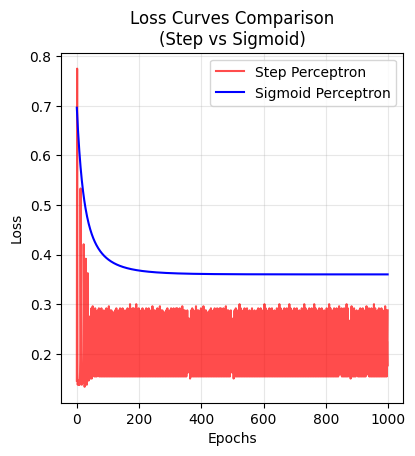

In [21]:
# ============================================
# PART 6: VISUALIZE LOSS FUNCTIONS
# ============================================
plt.figure(figsize=(15, 10))

# Plot 1: Loss curves over time
plt.subplot(2, 3, 1)
plt.plot(step_perceptron.losses, label='Step Perceptron', color='red', alpha=0.7)
plt.plot(sigmoid_perceptron.losses, label='Sigmoid Perceptron', color='blue')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curves Comparison\n(Step vs Sigmoid)')
plt.legend()
plt.grid(True, alpha=0.3)


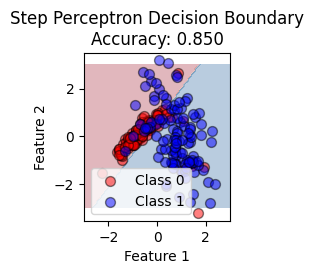

In [23]:
# Plot 2: Decision boundaries - Step Perceptron
plt.subplot(2, 3, 2)
xx, yy = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler.transform(grid)  # Scale the grid
predictions = step_perceptron.predict(grid_scaled)
predictions = predictions.reshape(xx.shape)
plt.contourf(xx, yy, predictions, alpha=0.3, cmap='RdBu')
plt.scatter(X_train[Y_train.flatten()==0, 0], X_train[Y_train.flatten()==0, 1], 
           c='red', label='Class 0', alpha=0.5, edgecolors='black', s=50)
plt.scatter(X_train[Y_train.flatten()==1, 0], X_train[Y_train.flatten()==1, 1], 
           c='blue', label='Class 1', alpha=0.5, edgecolors='black', s=50)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'Step Perceptron Decision Boundary\nAccuracy: {stepTestAccuracy:.3f}')
plt.legend()

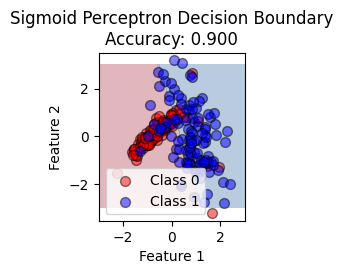

In [24]:
# Plot 3: Decision boundaries - Sigmoid Perceptron
plt.subplot(2, 3, 3)
predictions_sig = sigmoid_perceptron.predict(grid_scaled)
predictions_sig = predictions_sig.reshape(xx.shape)
plt.contourf(xx, yy, predictions_sig, alpha=0.3, cmap='RdBu')
plt.scatter(X_train[Y_train.flatten()==0, 0], X_train[Y_train.flatten()==0, 1], 
           c='red', label='Class 0', alpha=0.5, edgecolors='black', s=50)
plt.scatter(X_train[Y_train.flatten()==1, 0], X_train[Y_train.flatten()==1, 1], 
           c='blue', label='Class 1', alpha=0.5, edgecolors='black', s=50)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'Sigmoid Perceptron Decision Boundary\nAccuracy: {sigmoidTestAccuracy:.3f}')
plt.legend()

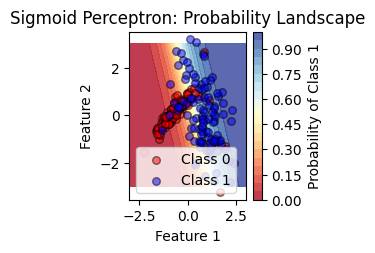

In [26]:
# Plot 4: Probability landscape (Sigmoid)
plt.subplot(2, 3, 4)
probabilities = sigmoid_perceptron.predictProbability(grid_scaled)
probabilities = probabilities.reshape(xx.shape)
contour = plt.contourf(xx, yy, probabilities, levels=20, alpha=0.8, cmap='RdYlBu')
plt.colorbar(contour, label='Probability of Class 1')
plt.scatter(X_train[Y_train.flatten()==0, 0], X_train[Y_train.flatten()==0, 1], 
           c='red', label='Class 0', alpha=0.5, edgecolors='black', s=30)
plt.scatter(X_train[Y_train.flatten()==1, 0], X_train[Y_train.flatten()==1, 1], 
           c='blue', label='Class 1', alpha=0.5, edgecolors='black', s=30)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Sigmoid Perceptron: Probability Landscape')
plt.legend()


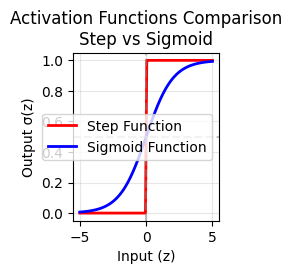

In [27]:
# Plot 5: Comparison of activation functions
plt.subplot(2, 3, 5)
x_vals = np.linspace(-5, 5, 100)
step_vals = np.where(x_vals >= 0, 1, 0)
sigmoid_vals = 1 / (1 + np.exp(-x_vals))

plt.plot(x_vals, step_vals, label='Step Function', linewidth=2, color='red')
plt.plot(x_vals, sigmoid_vals, label='Sigmoid Function', linewidth=2, color='blue')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Input (z)')
plt.ylabel('Output σ(z)')
plt.title('Activation Functions Comparison\nStep vs Sigmoid')
plt.legend()
plt.grid(True, alpha=0.3)

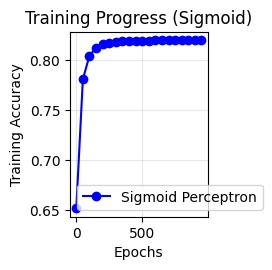

In [28]:
# Plot 6: Training accuracy over time
plt.subplot(2, 3, 6)
# Calculate running accuracy for sigmoid during training
sigmoid_accuracies = []
for i in range(0, len(sigmoid_perceptron.losses)):
    # Create temporary model with current weights (simplified)
    # For demonstration, we'll just show that accuracy improves as loss decreases
    if i % 50 == 0:
        sigmoid_accuracies.append(1 - sigmoid_perceptron.losses[i] / 2)  # Approximate mapping

plt.plot(range(0, len(sigmoid_perceptron.losses), 50), 
         sigmoid_accuracies, 'bo-', label='Sigmoid Perceptron')
plt.xlabel('Epochs')
plt.ylabel('Training Accuracy')
plt.title('Training Progress (Sigmoid)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()